## Running the Lorenz 1996 Model


### Introduction to the Lorenz, 1996 Model
The Lorenz 1996 Model is an idealised model of mid-latitude circulation. It is commonly used as a testbed for machine learning parameterisations (e.g., ), including stochastic parameterisations (e.g., ). Here, we will use it to identify aleatoric and epistemic uncertainty. These notebooks introduce the code. 
One layer model:
$$
\frac{dX_{k}}{dt} = -X_{k-1} (X_{k-2}-X_{k+1} ) -X_k + F 
$$

We can also extend this ot the Two Layer model:

$$
\frac{dX_{k}}{dt} = -X_{k-1} (X_{k-2}-X_{k+1} ) -X_k + F + \frac{-hc}{b} \Sigma_{j=J(k-1)+1}^{kJ} Y_j 
$$

$$
\frac{dY_{j}}{dt} = -cbY_{j+1} (Y_{j+2}-Y_{j-1} )-cY_j+\frac{ hc}{b}X_{int[j-1/J]+1} 
$$

- Coupled equations.
This can be thought of as a 'high resolution' version of the model, while the one layer is a 'low resolution' version. We can use this setup to learn a machine learning component (a parameterisation) that helps our low res, 1-layer version behave more like the 2-layer version. 
To do this, we will learn a parameterisation, U, which allows us to run the low-resolution model:
$$
\frac{dX_{k}}{dt} = -X_{k-1} (X_{k-2}-X_{k+1} ) -X_k + F + U
$$
Where the U approximately captures all the subgrid-processes (the Y terms), learned with a neural network.

First, import code

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Imports from this package: the L96 Two Layer Model and function to estimate subgrid component
from L96.L96_model import L96TwoLayer, subgrid_component


Define setup

In [ ]:

# Random seed
seed = 123
np.random.seed(seed)

# Define dimensions of system (fixed)
K = 8   
J = 32  

# Define the "true" parameters
h = 1
F = 20
c = 10
b = 10

# Define time-stepping, random seed
dt = 0.001
T = 1000
spinup_T = 1000



In [ ]:
# Save the data we generate to file
data_path = f'./outputs/'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# Random initial conditions
X0 = np.random.rand(K)
Y0 = np.random.rand(K*J)

# Set up model
lorenz_model = L96TwoLayer(X_0=X0, Y_0=Y0, F=F, c=c, b=b, h=h, dt=dt)
print(f"Lorenz 1996 model initialized. Spin-up {spinup_T}")
X, Y, U_true, time = lorenz_model.iterate(spinup_T)

print(f"Spin-up done. Running for time={T}...")
X, Y, U_true, time = lorenz_model.iterate(T)
print("Lorenz 1996 model run finished. Saving data...")

## Save full data at dt=0.001
np.save(f'{data_path}/X_full.npy', X)
np.save(f'{data_path}/U_true_full.npy', U_true)

# Save last X and Y for initialization of test simulations
np.save(f'{data_path}/X_init.npy', X[-1])
np.save(f'{data_path}/Y_init.npy', Y[-1])


Lorenz 1996 model initialized. Spin-up 1000
Spin-up done. Running for time=1000...
Lorenz 1996 model run finished. Saving data...
Subsampling data by factor 5 to dt_f = 0.005


We will run the low resolution model at a coarser timestep (more computationallty affordable), so we will use the X-data to approximate the subgrid-term U. This is also analagous to what we would do when learning the subgrid term from high resolution model data (ie coarsen the data over time and space, rather than just space). This creates our training data.

In [ ]:

## Save data at dt_f = 0.005 for training
subsample_factor = 5
dt_f = dt * subsample_factor
print(f"Subsampling data by factor {subsample_factor} to dt_f = {dt_f}")
X_all = X
X = X[::subsample_factor]
time_subsample = time[::subsample_factor]
U_est = subgrid_component(X[1:], X[:-1], dt_f, F)
np.save(f'{data_path}/U_train_dtf.npy', U_est)

X = X[1:]
np.save(f'{data_path}/X_train_dtf.npy', X)


In [6]:
X.shape

torch.Size([199999, 8])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


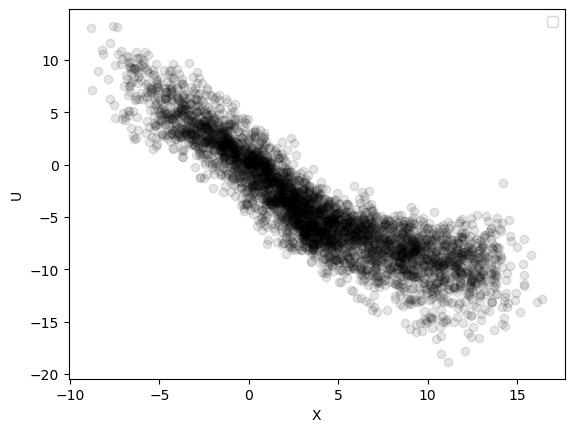

In [12]:
plt.clf()
plt.scatter(X[:10000:20], U_est[:10000:20], alpha=0.1, color="k")
plt.xlabel("X")
plt.ylabel("U")
plt.legend()


